In [2]:
import numpy as np

def polarization_fractions(E, B):
    """Return sigma_plus, sigma_minus, pi fractions of local |E|².

    E: complex Cartesian amplitudes, shape (..., 3), with exp(-i*omega*t).
    B: real nonzero vector, shape (3,), defining the quantization axis.
    sigma_plus drives delta_m = +1; no transition strengths are included.
    """
    E, B = np.asarray(E, dtype=complex), np.asarray(B, dtype=float)
    if E.ndim == 0 or E.shape[-1] != 3 or B.shape != (3,):
        raise ValueError("Expected E shape (..., 3) and B shape (3,).")
    if not np.all(np.isfinite(E)) or not np.all(np.isfinite(B)):
        raise ValueError("E and B must be finite.")
    total = np.sum(np.abs(E)**2, axis=-1)
    if np.linalg.norm(B) == 0 or np.any(total == 0):
        raise ValueError("B and the local electric field must be nonzero.")

    z = B / np.linalg.norm(B)
    ref = np.eye(3)[np.argmin(np.abs(z))]
    x = ref - np.dot(ref, z) * z
    x /= np.linalg.norm(x)
    y = np.cross(z, x)  # Right-handed frame aligned with B.
    Ex, Ey, Ez = E @ x, E @ y, E @ z
    return {
        "sigma_plus": np.abs((Ex - 1j*Ey) / np.sqrt(2))**2 / total,
        "sigma_minus": np.abs((Ex + 1j*Ey) / np.sqrt(2))**2 / total,
        "pi": np.abs(Ez)**2 / total,
    }


In [15]:
# Relative electric-field amplitudes in the laboratory x, y, z axes.
E = np.array([0.5j, 1+0.5, 0], dtype=complex)
B = np.array([0, 0, 1], dtype=float)  # B-field direction; any nonzero scale.

fractions = polarization_fractions(E, B)
for label, fraction in fractions.items():
    print(f"{label}: {fraction:.4f} ({fraction:.2%})")


sigma_plus: 0.2000 (20.00%)
sigma_minus: 0.8000 (80.00%)
pi: 0.0000 (0.00%)


**Theory: polarization relative to the magnetic field**

At the ion, write the real field as
$\mathbf E_{\mathrm{real}}(t)=\mathrm{Re}[\mathbf E e^{-i\omega t}]$.
The complex vector $\mathbf E$ contains relative amplitudes **and phases**.
Let $\hat{\mathbf z}'=\mathbf B/|\mathbf B|$ and choose transverse axes
$\hat{\mathbf x}',\hat{\mathbf y}'$ forming a right-handed frame.
Define $E_j'=\hat{\mathbf j}'\cdot\mathbf E$. These are components in the
B-aligned frame, not generally the laboratory components entered above.

The spherical polarization vectors are
$$
\boldsymbol\epsilon_0=\hat{\mathbf z}',\qquad
\boldsymbol\epsilon_\pm=\mp\frac{\hat{\mathbf x}'\pm i\hat{\mathbf y}'}{\sqrt{2}}.
$$
Project with the **complex conjugate**: $a_q=\boldsymbol\epsilon_q^*\cdot\mathbf E$.
For electric-dipole absorption, $q=+1,-1,0$ corresponds to
$\Delta m=+1,-1,0$ (respectively $\sigma_+,\sigma_-,\pi$).
With $S=\mathbf E^*\cdot\mathbf E$, the normalized intensities are
$$
f_\pi=\frac{|E_z'|^2}{S},\qquad
f_{\sigma_+}=\frac{|E_x'-iE_y'|^2}{2S},\qquad
f_{\sigma_-}=\frac{|E_x'+iE_y'|^2}{2S}.
$$
Orthonormality gives $f_\pi+f_{\sigma_+}+f_{\sigma_-}=1$.
The choice of transverse axes does not affect these fractions.

**What changes the fractions?**

- **Linear polarization:** for a real amplitude vector (up to a common phase),
  let $\theta$ be its angle to B. Then
  $f_\pi=\cos^2\theta$ and $f_{\sigma_+}=f_{\sigma_-}=\tfrac12\sin^2\theta$.
  Parallel gives pure $\pi$; perpendicular gives equal $\sigma$ fractions.
- **Relative phase:** in general,
  $f_{\sigma_+}-f_{\sigma_-}=2\,\mathrm{Im}(E_x'^*E_y')/S$.
  For $\mathbf B\parallel+\hat{\mathbf z}$, $\mathbf E\propto(1,i,0)$ is pure
  $\sigma_+$, whereas $(1,-i,0)$ is pure $\sigma_-$.
- **Reversing B:** exchanges $f_{\sigma_+}$ and $f_{\sigma_-}$ and leaves $f_\pi$ unchanged.
- **Scaling E:** any common nonzero complex factor cancels, so relative amplitudes suffice.

These are local polarization fractions. Actual electric-dipole excitation strengths
also include the relevant squared dipole matrix elements (Clebsch–Gordan factors).
For higher-multipole transitions, the electric-field vector alone is insufficient.

[Spherical-basis convention reference](https://www.sciencedirect.com/science/article/abs/pii/S0030401810012150).


**Step-by-step derivation**

**1. Represent amplitudes and phases.**

At the ion, use the convention
$$
\mathbf E_{\mathrm{real}}(t)=\mathrm{Re}[\mathbf E e^{-i\omega t}],
\qquad
\mathbf E=(A_xe^{i\phi_x},A_ye^{i\phi_y},A_ze^{i\phi_z}).
$$
Here $A_j\geq0$ are field amplitudes. Averaging over one optical cycle gives
$$
\left\langle|\mathbf E_{\mathrm{real}}(t)|^2\right\rangle
=\frac12\mathbf E^*\cdot\mathbf E
=\frac12\left(|E_x|^2+|E_y|^2+|E_z|^2\right).
$$
Thus the local polarization weights are squared complex amplitudes. The common
factor $1/2$ cancels when we normalize. Define $S=\mathbf E^*\cdot\mathbf E>0$.

**2. Rotate into a frame aligned with B.**

For nonzero B, set $\hat{\mathbf z}'=\mathbf B/|\mathbf B|$.
Choose a real unit vector $\mathbf r$ not parallel to $\hat{\mathbf z}'$ and construct
$$
\hat{\mathbf x}'=
\frac{\mathbf r-(\mathbf r\cdot\hat{\mathbf z}')\hat{\mathbf z}'}
{|\mathbf r-(\mathbf r\cdot\hat{\mathbf z}')\hat{\mathbf z}'|},
\qquad
\hat{\mathbf y}'=\hat{\mathbf z}'\times\hat{\mathbf x}'.
$$
The subtraction removes the component of $\mathbf r$ parallel to B.
The resulting axes are orthonormal and right-handed. Project the field:
$$
E_x'=\hat{\mathbf x}'\cdot\mathbf E,\qquad
E_y'=\hat{\mathbf y}'\cdot\mathbf E,\qquad
E_z'=\hat{\mathbf z}'\cdot\mathbf E.
$$
A rotation preserves the norm, so $S=|E_x'|^2+|E_y'|^2+|E_z'|^2$.

**3. Build the circular and longitudinal basis.**

The longitudinal vector is $\boldsymbol\epsilon_0=\hat{\mathbf z}'$.
Equal transverse amplitudes with a $\pm\pi/2$ phase difference give circular
polarization. For example,
$$
\mathrm{Re}[(\hat{\mathbf x}'+i\hat{\mathbf y}')e^{-i\omega t}]
=\hat{\mathbf x}'\cos\omega t+\hat{\mathbf y}'\sin\omega t.
$$
Normalizing these vectors gives the conventional spherical basis
$$
\boldsymbol\epsilon_+=-\frac{\hat{\mathbf x}'+i\hat{\mathbf y}'}{\sqrt2},\qquad
\boldsymbol\epsilon_-=\frac{\hat{\mathbf x}'-i\hat{\mathbf y}'}{\sqrt2},\qquad
\boldsymbol\epsilon_0=\hat{\mathbf z}'.
$$
The overall minus sign on $\boldsymbol\epsilon_+$ does not affect its intensity.
These vectors satisfy $\boldsymbol\epsilon_q^*\cdot\boldsymbol\epsilon_{q'}=\delta_{qq'}$.
Relative to B, they drive electric-dipole absorption with $\Delta m=+1,-1,0$.

**4. Extract each polarization amplitude.**

Expand the field as $\mathbf E=a_+\boldsymbol\epsilon_++a_-\boldsymbol\epsilon_-+a_0\boldsymbol\epsilon_0$.
Taking the complex-conjugate inner product with each basis vector isolates its coefficient:
$$
a_+=-\frac{E_x'-iE_y'}{\sqrt2},\qquad
a_-=\frac{E_x'+iE_y'}{\sqrt2},\qquad
a_0=E_z'.
$$
This conjugation is essential: omitting it exchanges the circular labels.

**5. Square the amplitudes and normalize.**

Using $f_q=|a_q|^2/S$, we obtain exactly the expressions in the code:
$$
\boxed{
f_{\sigma_+}=\frac{|E_x'-iE_y'|^2}{2S},\qquad
f_{\sigma_-}=\frac{|E_x'+iE_y'|^2}{2S},\qquad
f_\pi=\frac{|E_z'|^2}{S}.
}
$$
To check their sum, expand the circular terms:
$$
|E_x'\mp iE_y'|^2
=|E_x'|^2+|E_y'|^2\pm2\,\mathrm{Im}(E_x'^*E_y').
$$
The cross terms cancel when added, so
$$
f_{\sigma_+}+f_{\sigma_-}+f_\pi
=\frac{|E_x'|^2+|E_y'|^2+|E_z'|^2}{S}=1.
$$

**6. Identify the role of relative phase.**

Write $E_x'=A e^{i\alpha}$ and $E_y'=C e^{i\beta}$, with $A,C\geq0$.
Then $\mathrm{Im}(E_x'^*E_y')=AC\sin(\beta-\alpha)$, giving
$$
f_{\sigma_\pm}=\frac{A^2+C^2\pm2AC\sin(\beta-\alpha)}{2S}.
$$
In-phase transverse components give equal circular fractions. With $A=C$,
$E_z'=0$, and $\beta-\alpha=+\pi/2$, the result is pure $\sigma_+$;
changing that phase difference to $-\pi/2$ gives pure $\sigma_-$.

**7. Recover the angle formula for linear polarization.**

For linear polarization write $\mathbf E=E_0\hat{\mathbf u}$, where
$\hat{\mathbf u}$ is a real unit vector and $E_0$ may include a common phase.
If $\cos\theta=\hat{\mathbf u}\cdot\hat{\mathbf z}'$, then
$$
|E_z'|^2=|E_0|^2\cos^2\theta,\qquad
|E_x'|^2+|E_y'|^2=|E_0|^2\sin^2\theta,\qquad
\mathrm{Im}(E_x'^*E_y')=0.
$$
Since $S=|E_0|^2$, this yields
$$
\boxed{f_\pi=\cos^2\theta,\qquad
f_{\sigma_+}=f_{\sigma_-}=\frac12\sin^2\theta.}
$$
For the current inputs $\mathbf E=(0,1,0)$ and $\mathbf B=(0,0,1)$,
$\theta=\pi/2$, so $(f_{\sigma_+},f_{\sigma_-},f_\pi)=(1/2,1/2,0)$.
Any common nonzero scale or phase multiplying E cancels from every fraction.

These fractions describe the light; transition-specific dipole matrix elements
must still be included when computing excitation strengths.


**How integrated-grating experiments handle optical pumping — literature and connection to our calculation**

**A single linear polarization cannot favor one circular component.**
From our derivation,
$$
f_{\sigma_+}-f_{\sigma_-}
=\frac{2\,\mathrm{Im}(E_x'^*E_y')}{|\mathbf E|^2}.
$$
For a real field vector up to a common phase, this is zero for **every** B direction.
Rotating B changes the $\pi$ fraction but cannot make $f_{\sigma_+}\ne f_{\sigma_-}$.
Thus changing the relative *real* x/y/z amplitudes alone cannot produce directional pumping through circular-polarization selectivity.

**What has actually been demonstrated?**

| Strategy | Implementation and experimental evidence |
|---|---|
| **Generate circular polarization on chip** | Spektor et al. combined two guided inputs in an inverse-designed emitter, with relative amplitudes and phases set by an integrated splitter. They experimentally generated circularly polarized light at 461 nm in tantala. This demonstrates the photonic component for neutral-Sr applications, rather than trapped-ion pumping. [Spektor et al., *Optica* 10, 871–879 (2023), author manuscript, Figs. 1–2](https://arxiv.org/pdf/2206.11966). |
| **Overlap two coherent, linearly polarized grating beams** | Corsetti et al. split one 422-nm input on chip and emitted it through two differently oriented TE gratings. Their overlapping beams produced a stable, spatially varying polarization at an $^{88}\mathrm{Sr}^+$ ion. They measured position-dependent ground-Zeeman populations after a pumping pulse and demonstrated polarization-gradient cooling. This establishes control of the local circular imbalance, but is not a demonstration of arbitrary, near-perfect state preparation. [Corsetti et al., *Light: Science & Applications* 15, 57 (2026), Fig. 8](https://www.nature.com/articles/s41377-025-02094-4). |
| **Use frequency-selective pumping with mixed polarization** | Mehta et al. used integrated 729-nm light in $^{40}\mathrm{Ca}^+$ to selectively transfer population out of $S_{1/2},m_J=+1/2$ into $D_{5/2}$, followed by 854-nm repumping through $P_{3/2}$. Repetition accumulated population in $S_{1/2},m_J=-1/2$, which was not resonantly addressed. They reported preparation infidelity below $10^{-4}$. Unequal optical $\sigma$ fractions were not required. The 729-nm transition is electric quadrupole, so our electric-dipole fractions alone do not give its coupling strengths. [Mehta et al., *Nature* 586, 533–537 (2020), Methods A.5 in the author manuscript](https://arxiv.org/html/2002.02258). |

A related alternative for **hyperfine ions** is optical pumping combined with microwave transfers:
Leu et al. demonstrated 99.94% preparation fidelity in $^{43}\mathrm{Ca}^+$ at 28.8 mT
using linearly polarized $\sigma_+/\sigma_-$ light. This is a demonstrated atomic protocol
motivated by integrated optics; it does not itself demonstrate grating delivery.
[Leu et al., *Physical Review A* 110, L040402 (2024)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.110.L040402).

**How do two linear outputs create unequal circular fractions? — idealized calculation**

Suppose their fields at the ion are orthogonal and transverse to B:
$$
\mathbf E=A\hat{\mathbf x}'+C e^{i\phi}\hat{\mathbf y}',\qquad A,C\geq0.
$$
Our existing function then gives
$$
f_{\sigma_\pm}=\frac{A^2+C^2\pm2AC\sin\phi}{2(A^2+C^2)},\qquad f_\pi=0.
$$
For equal amplitudes, $f_{\sigma_\pm}=(1\pm\sin\phi)/2$:
$\phi=0$ gives a 50:50 mixture; $\phi=+\pi/2$ gives pure $\sigma_+$;
$\phi=-\pi/2$ gives pure $\sigma_-$.
For crossing beams, the local phase contains
$\phi(\mathbf r)=(\mathbf k_2-\mathbf k_1)\cdot\mathbf r+\phi_0$.
Thus path phase or ion position controls the ratio. This is an idealized explanation of
the interference mechanism; actual grating fields need not be perfectly orthogonal.
If the relative phase averages uniformly, the imbalance vanishes: merely adding two
incoherent linear beams is insufficient.

**Circular relative to the beam is not necessarily pure $\sigma_+$ relative to B.**

As a geometric consequence of our projection formula, for an ideal circular plane wave
whose handedness gives $\sigma_+$ when $\mathbf k\parallel\mathbf B$, at angle
$\theta$ between $\mathbf k$ and B,
$$
f_{\sigma_+}=\frac{(1+\cos\theta)^2}{4},\qquad
f_{\sigma_-}=\frac{(1-\cos\theta)^2}{4},\qquad
f_\pi=\frac{\sin^2\theta}{2}.
$$
At $90^\circ$ these are $(1/4,1/4,1/2)$: no circular imbalance.
For a focused grating beam, evaluate the full local complex field instead of assuming
one propagation direction. Corsetti et al. explicitly discuss orienting an additional
circular emitter along B for selective pumping. [Architecture discussion](https://www.nature.com/articles/s41377-025-02094-4).

**Implication for our grating.**
If only one fixed guided mode is excited, changing its input amplitude or global phase
only multiplies its emitted field by a scalar; its normalized fractions stay fixed.
To control the ratio optically, we need another independent coherent field component
with a controlled relative phase, or an emitter designed to produce the required ellipticity.
Use the simulated **complex** $E_x,E_y,E_z$ at the ion in `polarization_fractions`;
intensity-component maps alone do not determine the circular imbalance.

Finally, optical pumping requires repeated excitation and spontaneous decay to accumulate
population in a target state that is dark or weakly driven. A favorable $\sigma$ ratio
helps polarization-selective pumping, but the final population also depends on the ion's
level structure, detunings, branching ratios, and repump fields. Frequency-selective
protocols create this asymmetry through resonance conditions instead.


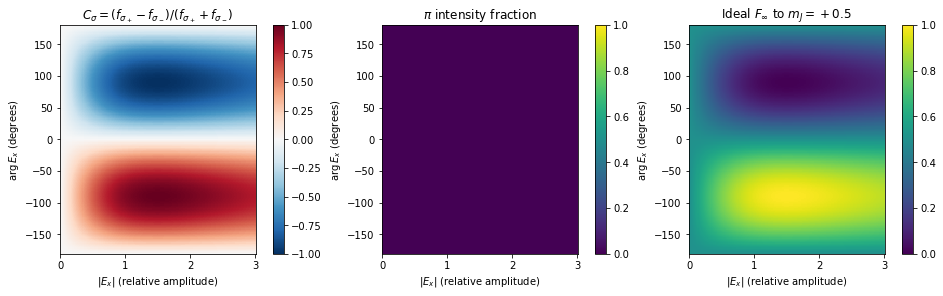

Best sampled ideal F_inf = 100.0000%: |E_x| = 1.5, phase = -90.0 degrees
At that point: sigma+ = 1.0000, sigma- = 0.0000, pi = 0.0000
Ideal steady-state model only; absolute power and pumping duration are not specified.


In [ ]:
import matplotlib.pyplot as plt

# Sweep controls: edit these, then rerun this cell.
E_magnitudes = np.abs(E).copy()            # Fixed laboratory x, y, z amplitudes
E_phases_deg = np.rad2deg(np.angle(E))     # Fixed laboratory x, y, z phases
B_sweep = np.asarray(B, dtype=float).copy()
sweep_component = "x"                    # Choose "x", "y", or "z"
magnitudes = np.linspace(0, 1, 500)       # Relative field amplitude, not intensity
phases_deg = np.linspace(-90, 180, 181)  # Phase relative to the fixed components
target_m = +0.5                          # Target ground state: +0.5 or -0.5

# Ideal closed J=1/2 -> J'=1/2, weak excitation, equal line-response factors,
# negligible atomic coherences, no metastable leakage or other relaxation.
# Squared CG factors: sigma = 2/3, pi = 1/3.
# Absorption followed by spin-changing decay gives:
# R(- -> +) = K*(2/9)*(f_sigma_plus + f_pi)
# R(+ -> -) = K*(2/9)*(f_sigma_minus + f_pi)
# dP+/dt = R(- -> +)*(1-P+) - R(+ -> -)*P+.
# Hence F_inf(+) = (f_sigma_plus + f_pi)/(f_sigma_plus + f_sigma_minus + 2*f_pi).
# This is a steady-state estimate, not a finite-pulse or species-specific fidelity.
# Rate-equation framework: https://pmc.ncbi.nlm.nih.gov/articles/PMC9890571/

if sweep_component not in ("x", "y", "z") or target_m not in (-0.5, 0.5):
    raise ValueError("Choose component x/y/z and target_m = +0.5 or -0.5.")
if (np.shape(E_magnitudes) != (3,) or np.shape(E_phases_deg) != (3,)
        or not np.all(np.isfinite(E_magnitudes)) or np.any(E_magnitudes < 0)
        or not np.all(np.isfinite(E_phases_deg))
        or not np.all(np.isfinite(magnitudes)) or np.any(magnitudes < 0)
        or not np.all(np.isfinite(phases_deg))):
    raise ValueError("Use three finite fixed amplitudes/phases and nonnegative amplitudes.")

A_grid, phase_grid = np.meshgrid(magnitudes, np.deg2rad(phases_deg))
E_fixed = E_magnitudes * np.exp(1j * np.deg2rad(E_phases_deg))
E_grid = np.broadcast_to(E_fixed, A_grid.shape + (3,)).copy()
E_grid[..., "xyz".index(sweep_component)] = A_grid * np.exp(1j * phase_grid)
valid = np.sum(np.abs(E_grid)**2, axis=-1) > 0
if not np.any(valid):
    raise ValueError("The sweep contains no nonzero electric fields.")
f_valid = polarization_fractions(E_grid[valid], B_sweep)
f_sweep = {key: np.full(A_grid.shape, np.nan) for key in f_valid}
for key in f_sweep:
    f_sweep[key][valid] = f_valid[key]
f_plus, f_minus, f_pi = (f_sweep[k] for k in ("sigma_plus", "sigma_minus", "pi"))
sigma_total = f_plus + f_minus
contrast = np.divide(f_plus - f_minus, sigma_total,
                     out=np.full_like(sigma_total, np.nan), where=sigma_total > 1e-14)
f_target = f_plus if target_m == 0.5 else f_minus
fidelity_inf = (f_target + f_pi) / (sigma_total + 2*f_pi)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
panels = [
    (contrast, r"$C_\sigma=(f_{\sigma_+}-f_{\sigma_-})/(f_{\sigma_+}+f_{\sigma_-})$", "RdBu_r", -1, 1),
    (f_pi, r"$\pi$ intensity fraction", "viridis", 0, 1),
    (fidelity_inf, rf"Ideal $F_\infty$ to $m_J={target_m:+.1f}$", "viridis", 0, 1),
]
for ax, (values, title, cmap, vmin, vmax) in zip(axes, panels):
    mesh = ax.pcolormesh(magnitudes, phases_deg, values, shading="auto",
                         cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set(xlabel=rf"$|E_{sweep_component}|$ (relative amplitude)",
           ylabel=rf"$\arg E_{sweep_component}$ (degrees)", title=title)
    ax.set_facecolor("0.85")  # Gray: zero E, or undefined sigma contrast.
    fig.colorbar(mesh, ax=ax)
plt.show()

best = np.unravel_index(np.nanargmax(fidelity_inf), fidelity_inf.shape)
print(f"Best sampled ideal F_inf = {fidelity_inf[best]:.4%}: "
      f"|E_{sweep_component}| = {A_grid[best]:.3g}, "
      f"phase = {np.rad2deg(phase_grid[best]):.1f} degrees")
print(f"At that point: sigma+ = {f_plus[best]:.4f}, "
      f"sigma- = {f_minus[best]:.4f}, pi = {f_pi[best]:.4f}")
print("Ideal steady-state model only; absolute power and pumping duration are not specified.")


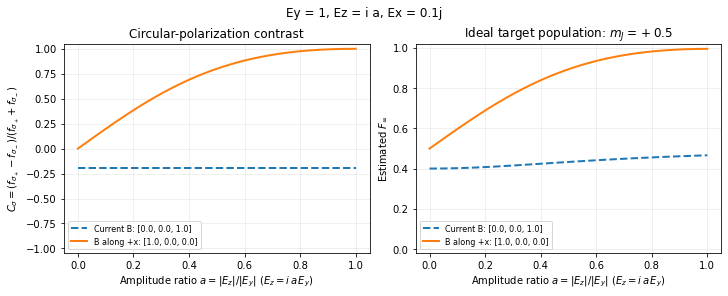

Current B: a=0 -> C=-0.198, F=40.1%; a=1 -> C=-0.198, F=46.7%
B along +x: a=0 -> C=0.000, F=50.0%; a=1 -> C=1.000, F=99.5%


In [20]:
import matplotlib.pyplot as plt

# Ey = 1; Ez = i*a (+90 degrees relative to Ey). a is an AMPLITUDE ratio.
a = np.linspace(0, 1, 501)  # Relative z/y intensity is a**2.
Ex_fixed = 0.1j              # Isolate the y-z pair; optionally set a fixed complex Ex.
target_m = +0.5            # Choose +0.5 or -0.5.
B_cases = [("Current B", np.asarray(B, dtype=float)),
           ("B along +x", np.array([1, 0., 0]))]
if target_m not in (-0.5, 0.5):
    raise ValueError("target_m must be +0.5 or -0.5.")
E_yz = np.column_stack([np.full(a.shape, Ex_fixed), np.ones_like(a), 1j*a])

# Same ideal closed J=1/2 -> J'=1/2 rate model as above:
# weak excitation, equal line-response factors, negligible atomic coherences,
# no metastable leakage or other relaxation; steady state, not a finite pulse.
# F_inf(+) = (f_plus + f_pi)/(f_plus + f_minus + 2*f_pi).
# For Ex=0 and B along +x: C_sigma=2*a/(1+a**2), F_inf(+)=(1+C_sigma)/2.
# For Ex=0 and B along z: C_sigma=0 and F_inf=1/2 at every a.
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
yz_results = {}
for (label, B_case), style in zip(B_cases, ["--", "-"]):
    f = polarization_fractions(E_yz, B_case)
    fp, fm, fpi = (f[k] for k in ("sigma_plus", "sigma_minus", "pi"))
    sigma = fp + fm
    C = np.divide(fp - fm, sigma, out=np.full_like(sigma, np.nan),
                  where=sigma > 1e-14)
    F = ((fp if target_m == 0.5 else fm) + fpi) / (sigma + 2*fpi)
    yz_results[label] = {"fractions": f, "contrast": C, "fidelity": F}
    legend = f"{label}: {B_case.tolist()}"
    axes[0].plot(a, C, style, label=legend, linewidth=2)
    axes[1].plot(a, F, style, label=legend, linewidth=2)

axes[0].set(ylabel=r"$C_\sigma=(f_{\sigma_+}-f_{\sigma_-})/(f_{\sigma_+}+f_{\sigma_-})$",
            title="Circular-polarization contrast", ylim=(-1.05, 1.05))
axes[1].set(ylabel=r"Estimated $F_\infty$",
            title=rf"Ideal target population: $m_J={target_m:+.1f}$", ylim=(-0.02, 1.02))
for ax in axes:
    ax.set_xlabel(r"Amplitude ratio $a=|E_z|/|E_y|$ ($E_z=i\,a\,E_y$)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle(f"Ey = 1, Ez = i a, Ex = {Ex_fixed}")
plt.show()

for label, result in yz_results.items():
    print(f"{label}: a=0 -> C={result['contrast'][0]:.3f}, F={result['fidelity'][0]:.1%}; "
          f"a=1 -> C={result['contrast'][-1]:.3f}, F={result['fidelity'][-1]:.1%}")
